# Naive Bayes

Imports and helpers

In [1]:
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.naive_bayes import MultinomialNB
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import numpy as np

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [5]:
X_test = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 50000)
y_test shape: (20000,)


## Model Training

model setup and random search 

In [6]:
nb_model = MultinomialNB()
nb_params = {'alpha': loguniform(1e-3, 1e1), 
                 'fit_prior': [True, False]}

Initialize RandomizedSearchCV (3-fold cross-validation acts as our validation set)

In [7]:
nb_search = RandomizedSearchCV(nb_model, nb_params, 
                               n_iter=60, cv=5, scoring='accuracy', 
                               random_state=42, n_jobs=-1, verbose=1)

Extract best models

In [8]:
print("\nTraining Naive Bayes...")
start_time = time.time()
nb_search.fit(X_train, y_train)
best_nb = nb_search.best_estimator_
nb_train_time = time.time() - start_time
print(f"Completed in {nb_train_time:.2f}s.")
print(f"Best NB Params: {nb_search.best_params_}")


Training Naive Bayes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


Completed in 19.85s.
Best NB Params: {'alpha': np.float64(1.2604664585649468), 'fit_prior': False}


## Model Evaluation

Predict on the X_valid 

In [9]:
y_valid_pred = best_nb.predict(X_valid)
print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")

Validation Accuracy: 0.8600


confusion matrices

In [10]:
print("\nClassification Report:")
print(classification_report(y_valid, y_valid_pred, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86     10003
    Positive       0.86      0.85      0.86      9997

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on tr

## Model Testing

Predict on the X_test 

In [11]:
y_test_pred = best_nb.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Test Accuracy: 0.8600


confusion matrices

In [12]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      9966
    Positive       0.86      0.86      0.86     10034

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on test dataset

## visualizations (validation and testing Confusion Matrix)

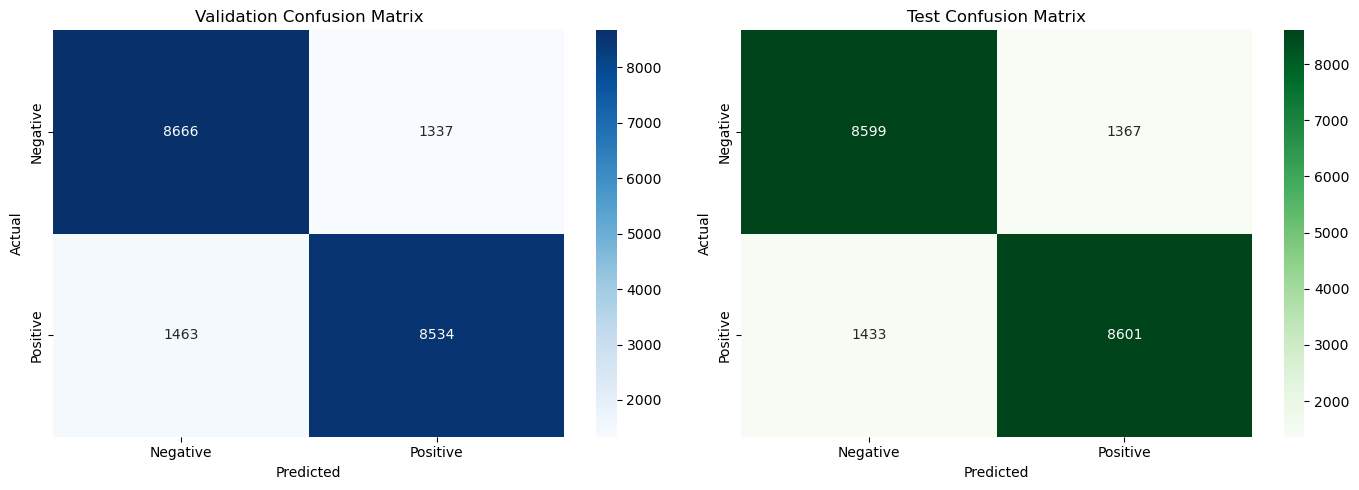

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = best_nb.classes_
ticklabels = ['Negative', 'Positive']

sns.heatmap(confusion_matrix(y_valid, y_valid_pred, labels=classes), 
            annot=True, fmt='d', cmap='Blues', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_test_pred, labels=classes), 
            annot=True, fmt='d', cmap='Greens', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Feature Inspection & Saving

feature_log_prob_[0] is negative class, [1] is positive class

In [14]:
vec_path = Path('data/vectorizers/tfidf_vectorizer.joblib')
if vec_path.exists():
    vectorizer = joblib.load(vec_path)
    feature_names = np.array(vectorizer.get_feature_names_out())

    neg_class_prob_sorted = best_nb.feature_log_prob_[0, :].argsort()[::-1]
    pos_class_prob_sorted = best_nb.feature_log_prob_[1, :].argsort()[::-1]
    
    print('\nTop features indicating Positive sentiment:')
    for i in pos_class_prob_sorted[:15]: 
        print(f"{feature_names[i]:<15} {best_nb.feature_log_prob_[1, i]:.4f}")

    print('\nTop features indicating Negative sentiment:')
    for i in neg_class_prob_sorted[:15]: 
        print(f"{feature_names[i]:<15} {best_nb.feature_log_prob_[0, i]:.4f}")


Top features indicating Positive sentiment:
book            -5.5286
great           -5.8253
not             -5.8276
but             -5.9748
one             -6.0565
very            -6.1054
good            -6.1312
love            -6.1968
like            -6.2554
read            -6.3198
movie           -6.3876
well            -6.4115
time            -6.4214
cd              -6.5023
would           -6.5047

Top features indicating Negative sentiment:
not             -5.1702
book            -5.6727
but             -5.7870
would           -6.0625
one             -6.0780
like            -6.2675
very            -6.3313
no              -6.3338
movie           -6.3513
time            -6.3924
get             -6.4093
product         -6.4756
good            -6.5207
even            -6.5825
money           -6.6159


## Saving the Model and Pipeline

In [ ]:
save(model_base='data/models', model=best_nb, model_name='06_naive_bayes_classifier.joblib')

Saved model best_naive_bayes.joblib to data/models/best_naive_bayes.joblib


{'model': PosixPath('data/models/best_naive_bayes.joblib')}

## Observation